In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/pairwise_approach_probability.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/pairwise_approach_probability.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/pairwise_approach_probability.csv')
df3['Condition'] = 'GH Starved-Starved'



df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/pairwise_approach_probability.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/pairwise_approach_probability.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/pairwise_approach_probability.csv')
df6['Condition'] = 'SI Starved-Starved'

df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)


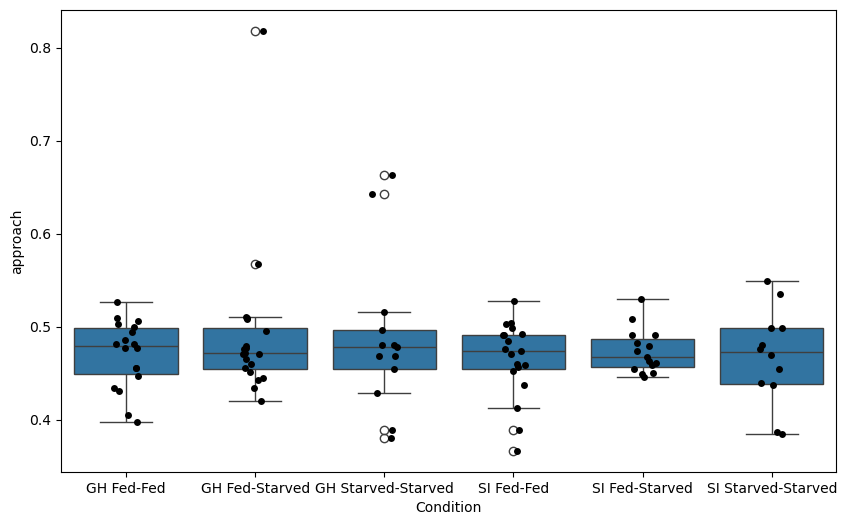

In [3]:
summary = (
    df.groupby(['Condition', 'file'])['approach']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))


sns.boxplot(data=summary,
            x='Condition',
            y='approach')
sns.stripplot(data=summary,
              x='Condition',
              y='approach',
              color='black')

plt.show()



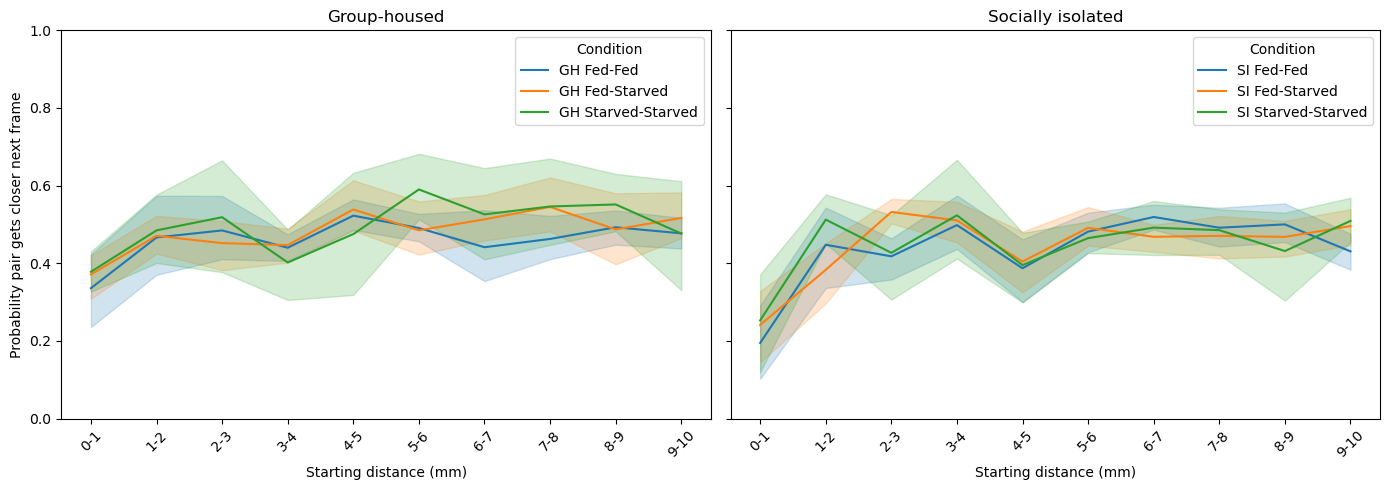

In [6]:
df['distance_bin'] = pd.cut(
    df['distance'],
    bins=np.arange(0, 11, 1),
    include_lowest=True
)

prob = (
    df.groupby(['Condition', 'file', 'distance_bin'])['approach']
    .mean()
    .reset_index(name='approach_probability')
)

prob['distance_midpoint'] = prob['distance_bin'].apply(lambda x: x.mid).astype(float)

si_prob = prob[prob['Condition'].str.contains('SI')]
gh_prob = prob[prob['Condition'].str.contains('GH')]


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.lineplot(
    data=gh_prob,
    x='distance_midpoint',
    y='approach_probability',
    hue='Condition',
        errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Starting distance (mm)')
axes[0].set_ylabel('Probability pair gets closer next frame')
axes[0].set_xticks(np.arange(0.5, 10.5, 1))
axes[0].set_xticklabels([f'{i}-{i+1}' for i in range(10)], rotation=45)
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=si_prob,
    x='distance_midpoint',
    y='approach_probability',
    hue='Condition',
        errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Starting distance (mm)')
axes[1].set_ylabel('')
axes[1].set_xticks(np.arange(0.5, 10.5, 1))
axes[1].set_xticklabels([f'{i}-{i+1}' for i in range(10)], rotation=45)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

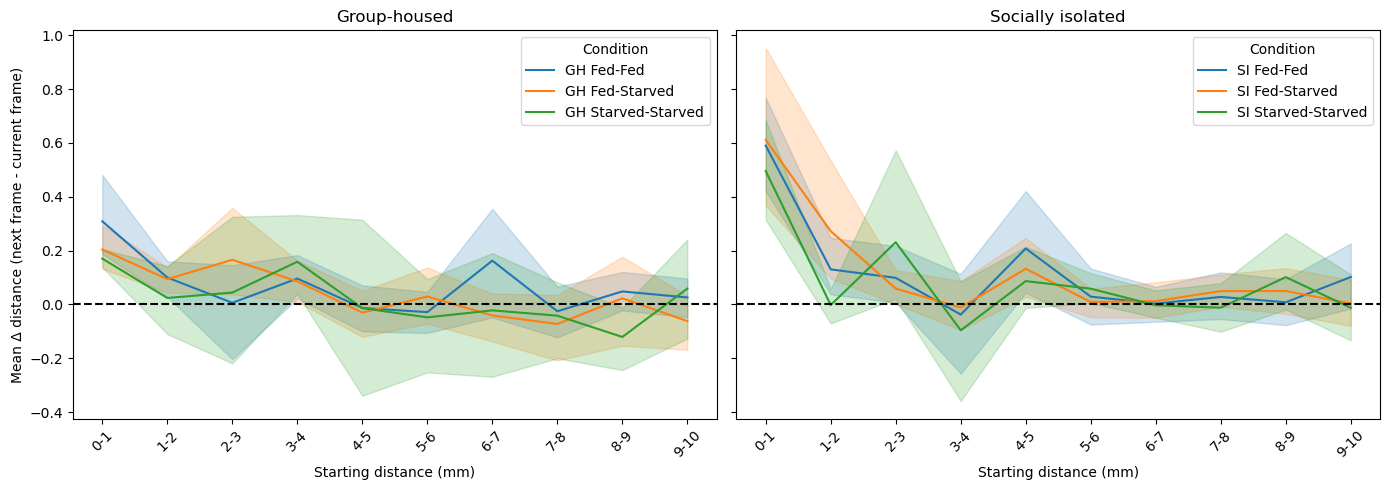

In [7]:
delta = (
    df.groupby(['Condition', 'file', 'distance_bin'])['delta_distance']
    .mean()
    .reset_index()
)

delta['distance_midpoint'] = (
    delta['distance_bin']
    .apply(lambda x: x.mid)
    .astype(float)
)

si_delta = delta[delta['Condition'].str.contains('SI')]
gh_delta = delta[delta['Condition'].str.contains('GH')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.lineplot(
    data=gh_delta,
    x='distance_midpoint',
    y='delta_distance',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axhline(0, linestyle='--', color='black')
axes[0].set_title('Group-housed')
axes[0].set_xlabel('Starting distance (mm)')
axes[0].set_ylabel('Mean Δ distance (next frame - current frame)')
axes[0].set_xticks(np.arange(0.5, 10.5, 1))
axes[0].set_xticklabels([f'{i}-{i+1}' for i in range(10)], rotation=45)

sns.lineplot(
    data=si_delta,
    x='distance_midpoint',
    y='delta_distance',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axhline(0, linestyle='--', color='black')
axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Starting distance (mm)')
axes[1].set_ylabel('')
axes[1].set_xticks(np.arange(0.5, 10.5, 1))
axes[1].set_xticklabels([f'{i}-{i+1}' for i in range(10)], rotation=45)

plt.tight_layout()
plt.show()